In [49]:
DATASET_NAME = "mimic_iv_cohort"
TEST_SIZE = 0.2
SEED = 4

In [35]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '..'
  SRC = f"{PROJECT_ROOT}/src"
  if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
  if SRC not in sys.path:
    sys.path.append(SRC)

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from config import Config

In [37]:

cohort = pd.read_csv(f"{PROJECT_ROOT}/{Config.DATA_DIR}/{DATASET_NAME}.csv")

In [38]:
print(f"Current features: {cohort.shape[1] - 1}")
print(f"Current population: {cohort.shape[0]}")

Current features: 70
Current population: 13890


# Missingness

- Remove features with more than 25% missing values
- Remove rows with more than 20% features missing
- Multivariate imputer for remaining missing values (in the training loop, stratified by ethnicity)

## Drop columns

In [39]:
# Drop columns with > 25% missing values in any ethnicity subgroup
missing_ratio = cohort.isna().mean()
subgroup_missing = cohort.isna().groupby(cohort['race_group']).mean()

cols_to_drop = list(set(missing_ratio[missing_ratio > 0.25].index.tolist() + subgroup_missing.columns[(subgroup_missing > 0.25).any()].tolist()))

study_dataset = cohort.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Remaining features: {study_dataset.shape[1] - 1}")
print(f"Current population: {study_dataset.shape[0]}")

Dropped 9 columns: ['ck_cpk_min', 'ck_mb_min', 'ck_cpk_max', 'ntbnp_min', 'bilirubin_max', 'pao2_min', 'ck_mb_max', 'fio2_max', 'ntbnp_max']
Remaining features: 61
Current population: 13890


## Sieve analysis

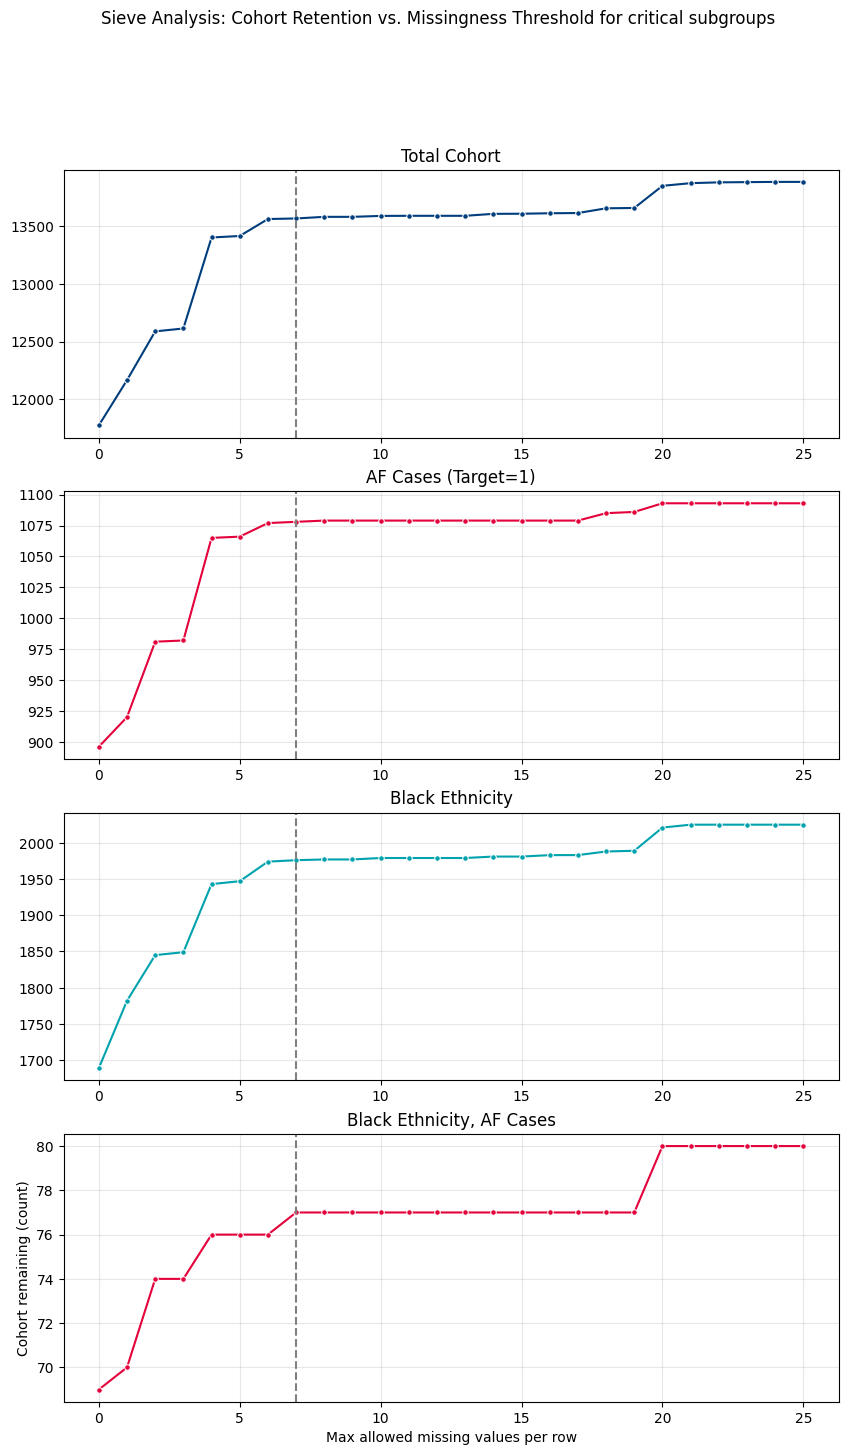

In [40]:
df_af = study_dataset[study_dataset['target_noaf'] == 1]
df_non_white = study_dataset[study_dataset['race_group'] != 0]
df_non_white_af = df_non_white[df_non_white['target_noaf'] == 1]

groups = {
  'Total Cohort': study_dataset,
  'AF Cases (Target=1)': df_af,
  'Black Ethnicity': df_non_white,
  'Black Ethnicity, AF Cases': df_non_white_af
}

thresholds = range(0, 26)
results = {name: [] for name in groups.keys()}

for t in thresholds:
  for name, subset in groups.items():
    # Count how many in this subset have <= t missing values
    n_missing = subset.isna().sum(axis=1)
    n_retained = len(subset) - sum(n_missing > t)
    results[name].append(n_retained)

fig, axes = plt.subplots(4, 1, figsize=(10, 16))
colors = ['#003d7c', '#e4003a', '#00a3ad', '#e4003a']
ax_idx = [0, 1, 2, 3]

for (name, counts), color, ax in zip(results.items(), colors, ax_idx):
  sns.lineplot(x=thresholds, y=counts, color=color, marker='o', markersize=4, ax=axes[ax])
  axes[ax].axvline(x=7, color='gray', linestyle='--', label='Candidate Threshold (20)')
  axes[ax].grid(True, alpha=0.3)
  axes[ax].set_title(name)

plt.suptitle('Sieve Analysis: Cohort Retention vs. Missingness Threshold for critical subgroups')
plt.xlabel('Max allowed missing values per row')
plt.ylabel('Cohort remaining (count)')
plt.show()

# Interpretation:
# If the three lines stay close together, the missingness is non differential, 
# i.e. low quality rows are distributed evenly across the population 
# and can be dealt with without introducing selection bias
# If the Non-White and AF lines drop significantly faster than the global population => differential missingness
# => relax the threshold or use imputation to preserve sample diversity
# However, this can show how data processing might affect bias in datasets

## Drop rows

In [41]:
# Drop rows with more than 7% missing features before imputation
chosen_threshold = 0.07
max_missing = study_dataset.shape[1] * chosen_threshold

missing_per_row = study_dataset.isna().sum(axis=1)

study_dataset = study_dataset.loc[missing_per_row <= max_missing, :].copy()

print(f"Rows dropped: {(missing_per_row > max_missing).sum(axis=0)}")
print(f"Remaining cohort size: {len(study_dataset)}")
print(f"Features: {study_dataset.shape[1]}")
print("Class and ethinicity split:")
print(study_dataset.groupby(['target_noaf','race_group']).size())

Rows dropped: 487
Remaining cohort size: 13403
Features: 62
Class and ethinicity split:
target_noaf  race_group
0            0             10471
             1              1867
1            0               989
             1                76
dtype: int64


## Missingness matrix

<Axes: >

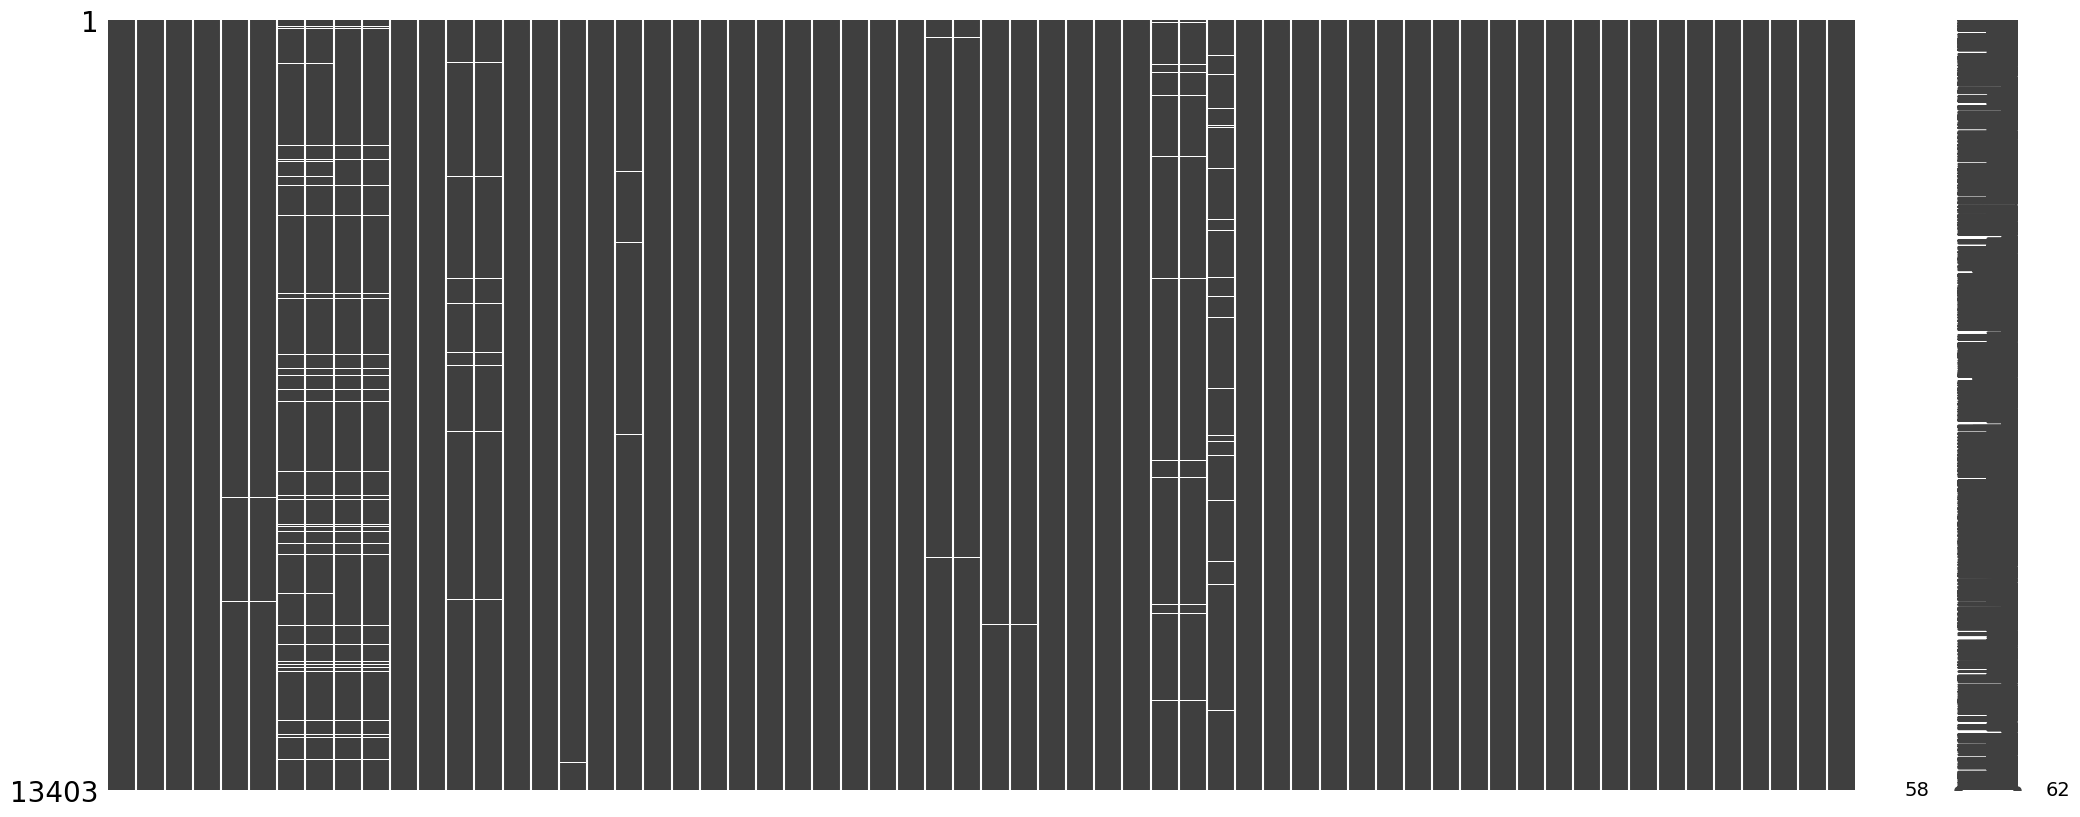

In [43]:
msno.matrix(study_dataset)

# Down sampling

In [45]:
print(pd.crosstab(study_dataset['race_group'], study_dataset['target_noaf']))

target_noaf      0    1
race_group             
0            10471  989
1             1867   76


In [46]:
def frequency_matched_sample(df, target_col='target_noaf', strata_cols=['gender', 'age_quantile', 'race_group']):
  """
  Performs 1:1 matching within each combined demographic and ethnic stratum.
  """
  matched_data = []
  
  # Group by Sex, Age, AND Ethnicity to ensure 1:1 matching within every subgroup
  for strata_values, group in df.groupby(strata_cols, observed=True):
    cases = group[group[target_col] == 1]
    controls = group[group[target_col] == 0]
    
    # Determine the number of pairs possible for this specific subgroup
    n_match = min(len(cases),len(controls))
    
    if n_match > 0:
      # Randomly sample to achieve 1:1 ratio
      sampled_cases = cases.sample(n_match, random_state=42)
      sampled_controls = controls.sample(n_match, random_state=42)
      
      matched_data.append(sampled_cases)
      matched_data.append(sampled_controls)
          
  return pd.concat(matched_data).reset_index(drop=True)

In [47]:
study_dataset['age_quantile'] = pd.qcut(study_dataset['admission_age'], q=4, labels=range(4))

balanced_dataset = frequency_matched_sample(study_dataset)

balanced_dataset.drop(['age_quantile'], axis=1, inplace=True)

print(f"Original Cohort Size: {len(study_dataset)}")
print(f"Balanced Cohort Size: {len(balanced_dataset)}")
print(f"Balanced AF Ratio: {balanced_dataset['target_noaf'].mean():.2%}")
print("\nMatched Case-Control counts by Ethnicity:")
print(pd.crosstab(balanced_dataset['race_group'], balanced_dataset['target_noaf']).to_markdown())

Original Cohort Size: 13403
Balanced Cohort Size: 2130
Balanced AF Ratio: 50.00%

Matched Case-Control counts by Ethnicity:
|   race_group |   0 |   1 |
|-------------:|----:|----:|
|            0 | 989 | 989 |
|            1 |  76 |  76 |


## TRAINING / TEST split

In [50]:
from sklearn.model_selection import train_test_split

strata = balanced_dataset[['target_noaf', 'race_group']]

train_df, test_df = train_test_split(
  balanced_dataset, 
  test_size=TEST_SIZE, 
  stratify=strata, 
  random_state=SEED
)

In [51]:
print(f"CEVAE-HE Training Set Size: {len(train_df)}")
print(f"CEVAE-HE Test and Classifier Bootstrap Set Size: {len(test_df)}")

print("\nTraining Set Ethnicity Distribution by Target Outcome:")
print(pd.crosstab(train_df['race_group'], train_df['target_noaf']).to_markdown())

print("\nTest Set Ethnicity Distribution by Target Outcome:")
print(pd.crosstab(test_df['race_group'], test_df['target_noaf']).to_markdown())

CEVAE-HE Training Set Size: 1704
CEVAE-HE Test and Classifier Bootstrap Set Size: 426

Training Set Ethnicity Distribution by Target Outcome:
|   race_group |   0 |   1 |
|-------------:|----:|----:|
|            0 | 791 | 791 |
|            1 |  61 |  61 |

Test Set Ethnicity Distribution by Target Outcome:
|   race_group |   0 |   1 |
|-------------:|----:|----:|
|            0 | 198 | 198 |
|            1 |  15 |  15 |


# Global Scaling

This is a conscious choice, as I need to train my CEVAE-HE before training my classifiers, and therefore need a consistently scaled dataset rather than applying scaling within bootstrapping loops